# Baseline 回帰モデル解析
このノートブックでは、ローカルの電力データと Open‑Meteo の気象データを結合し、簡単な線形回帰を適用して予測結果を可視化・比較します。

In [13]:
import os
PROJECT_ROOT = os.path.abspath('..')   # notebooks/ の一つ上を想定
power_fp = os.path.join(PROJECT_ROOT, 'src', 'data', 'raw', '202603_power_usage', '20260327_power_usage.csv')
print('power_fp ->', power_fp)
print('exists ->', os.path.exists(power_fp))
import sys
# プロジェクトルートを PYTHONPATH に追加（notebook を notebooks/ から開いた場合を想定）
sys.path.append(os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
from src.data.load_power import load_clean_power_data
from src.data.fetch_weather import fetch_weather
from src.features.build_features import build_features
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
plt.rcParams['figure.figsize'] = (12,5)

power_fp -> /Users/aoiendo/MyProjects/PowerForcaster/src/data/raw/202603_power_usage/20260327_power_usage.csv
exists -> True


In [14]:
# 電力データ読み込み（raw 配下の全CSVを集約して正規化）
from src.data.load_power import load_all_power_data
raw_dir = os.path.join(PROJECT_ROOT, 'src', 'data', 'raw')
power = load_all_power_data(raw_dir)
print('power shape:', power.shape)
if power.empty:
    import glob
    files = glob.glob(os.path.join(raw_dir, '**', '*.csv'), recursive=True)
    print('No power data loaded. Checked:', raw_dir)
    print('Found csv files (first 20):', files[:20])
    print('If you expected data, ensure CSVs are placed under src/data/raw/<yyyymm>/ and retry.')
else:
    print(power.head())

power shape: (2088, 4)
                           power  predicted_power  usage_rate  capacity
time                                                                   
2026-01-01 00:00:00+09:00   2667             2687          89      2987
2026-01-01 01:00:00+09:00   2545             2548          89      2847
2026-01-01 02:00:00+09:00   2490             2496          88      2803
2026-01-01 03:00:00+09:00   2457             2468          86      2831
2026-01-01 04:00:00+09:00   2445             2463          86      2836


In [16]:
# 気象データ取得（過去1日分）
weather = fetch_weather(past_days=10)
print('weather shape:', weather.shape)
print(weather[['time','temperature_2m','relativehumidity_2m','precipitation']].head())

weather shape: (408, 4)
                       time  temperature_2m  relativehumidity_2m  \
0 2026-03-19 00:00:00+09:00            11.3                   83   
1 2026-03-19 01:00:00+09:00            11.5                   81   
2 2026-03-19 02:00:00+09:00            11.7                   85   
3 2026-03-19 03:00:00+09:00            11.7                   89   
4 2026-03-19 04:00:00+09:00            12.1                   93   

   precipitation  
0            0.0  
1            0.1  
2            0.0  
3            0.0  
4            0.0  


In [4]:
# 特徴量作成（電力と気象を最近傍で結合）
# power が DatetimeIndex を持っているか確認してから build_features を呼ぶ
print('power index type ->', type(power.index))
if power.empty:
    print('power DataFrame is empty. Skipping feature building. Ensure CSVs exist under src/data/raw.')
    df = pd.DataFrame()
else:
    if not isinstance(power.index, pd.DatetimeIndex) and 'time' not in power.columns:
        raise ValueError('power DataFrame must have DatetimeIndex or a time column; got: ' + str(power.shape))
    df = build_features(power, weather)
    print('merged shape:', df.shape)
    print('columns:', df.columns.tolist())
    print(df.head())

power index type -> <class 'pandas.DatetimeIndex'>
merged shape: (2088, 15)
columns: ['power', 'predicted_power', 'usage_rate', 'capacity', 'temperature_2m', 'relativehumidity_2m', 'precipitation', 'hour', 'dayofweek', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'ma_3', 'ma_24']
                           power  predicted_power  usage_rate  capacity  \
time                                                                      
2026-01-01 00:00:00+09:00   2667             2687          89      2987   
2026-01-01 01:00:00+09:00   2545             2548          89      2847   
2026-01-01 02:00:00+09:00   2490             2496          88      2803   
2026-01-01 03:00:00+09:00   2457             2468          86      2831   
2026-01-01 04:00:00+09:00   2445             2463          86      2836   

                           temperature_2m  relativehumidity_2m  precipitation  \
time                                                                            
2026-01-01 00:00:00+09:00       

In [17]:
# 特徴量と目的変数の準備
can_proceed = True
if df is None or df.empty:
    print('No feature DataFrame available. Skipping model prep.')
    can_proceed = False
else:
    candidate_feats = ['temperature_2m','relativehumidity_2m','precipitation', 'lag_1','lag_24','lag_168','ma_3','ma_24','hour','dayofweek','is_weekend']
    feature_cols = [c for c in candidate_feats if c in df.columns]
    target_col = 'power'
    print('selected features ->', feature_cols)
    print('na counts ->', df[feature_cols + [target_col]].isna().sum().to_dict())
    df_model = df.dropna(subset=feature_cols + [target_col])
    n = len(df_model)
    print('usable rows after dropna:', n)
    if n == 0:
        print('No usable rows for modeling after dropping NA. Adjust features or imputation.')
        can_proceed = False
    else:
        split = int(n * 0.75)
        X_train = df_model[feature_cols].iloc[:split]
        X_test = df_model[feature_cols].iloc[split:]
        y_train = df_model[target_col].iloc[:split]
        y_test = df_model[target_col].iloc[split:]

selected features -> ['temperature_2m', 'relativehumidity_2m', 'precipitation', 'lag_1', 'lag_24', 'lag_168', 'ma_3', 'ma_24', 'hour', 'dayofweek', 'is_weekend']
na counts -> {'temperature_2m': 2064, 'relativehumidity_2m': 2064, 'precipitation': 2064, 'lag_1': 1, 'lag_24': 24, 'lag_168': 168, 'ma_3': 0, 'ma_24': 0, 'hour': 0, 'dayofweek': 0, 'is_weekend': 0, 'power': 0}
usable rows after dropna: 24


In [18]:
# 単純な線形回帰を学習して評価・予測
if not globals().get('can_proceed', False):
    print('Skipping LinearRegression: insufficient data or features.')
else:
    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    print('Linear MAE:', mae)
    print('Linear MSE:', mse)

Linear MAE: 135.3844888194757
Linear MSE: 20735.579039012984


RF MAE: 82.92666666666666
RF MSE: 8860.386566666664


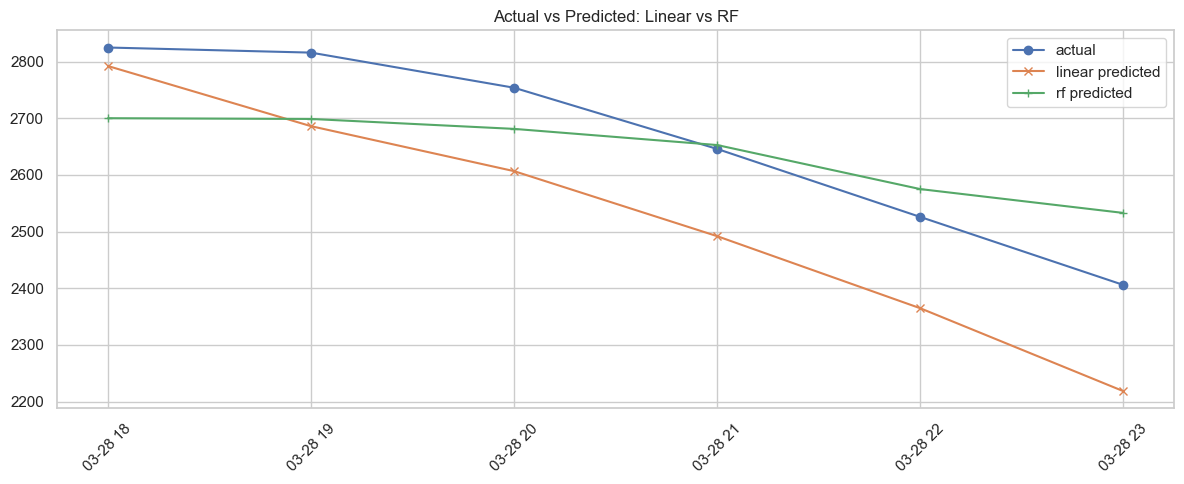

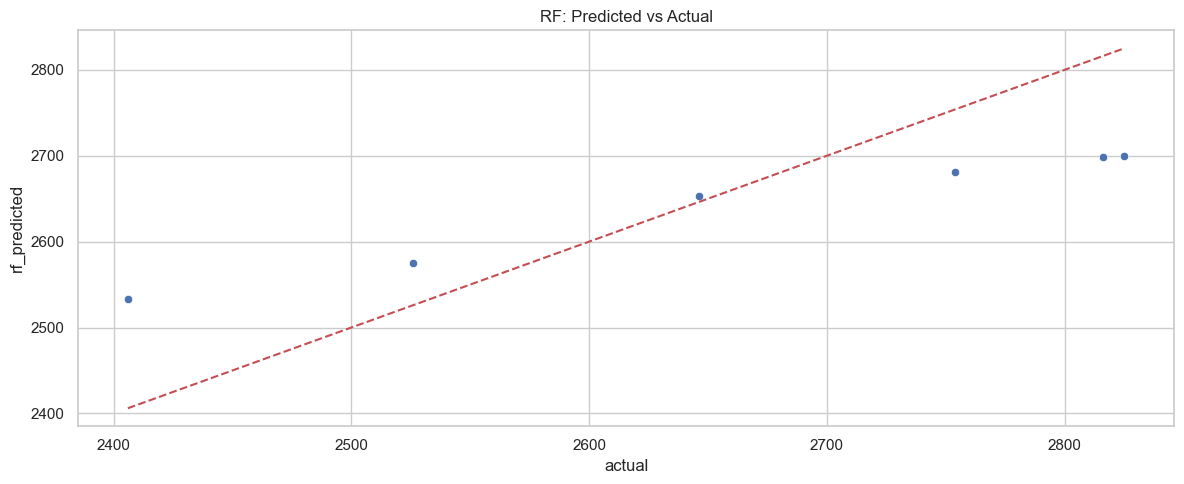

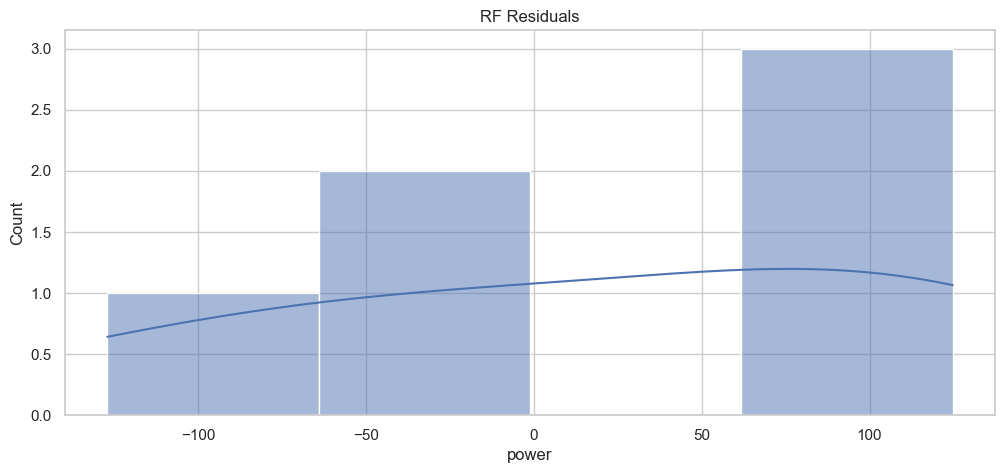

In [19]:
# 追加: 簡易パイプラインでランダムフォレストを学習・比較（欠損は平均で埋める）
if not globals().get('can_proceed', False):
    print('Skipping RandomForest training: insufficient data or features.')
else:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.impute import SimpleImputer
    import numpy as np
    # Impute missing features with mean (fit on train)
    imp = SimpleImputer(strategy='mean')
    X_train_imp = imp.fit_transform(X_train)
    X_test_imp = imp.transform(X_test)
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_imp, y_train)
    rf_preds = rf.predict(X_test_imp)
    rf_mae = mean_absolute_error(y_test, rf_preds)
    rf_mse = mean_squared_error(y_test, rf_preds)
    print('RF MAE:', rf_mae)
    print('RF MSE:', rf_mse)
    # 可視化: テスト期間で線形 vs RF を比較
    plt.figure()
    plt.plot(y_test.index, y_test, label='actual', marker='o')
    plt.plot(y_test.index, preds, label='linear predicted', marker='x')
    plt.plot(y_test.index, rf_preds, label='rf predicted', marker='+')
    plt.legend()
    plt.title('Actual vs Predicted: Linear vs RF')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    # 散布図: RF の予測 vs 実測
    plt.figure()
    sns.scatterplot(x=y_test, y=rf_preds)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('actual')
    plt.ylabel('rf_predicted')
    plt.title('RF: Predicted vs Actual')
    plt.tight_layout()
    plt.show()
    # 残差ヒストグラム（RF）
    resid_rf = y_test - rf_preds
    plt.figure()
    sns.histplot(resid_rf, kde=True)
    plt.title('RF Residuals')
    plt.show()

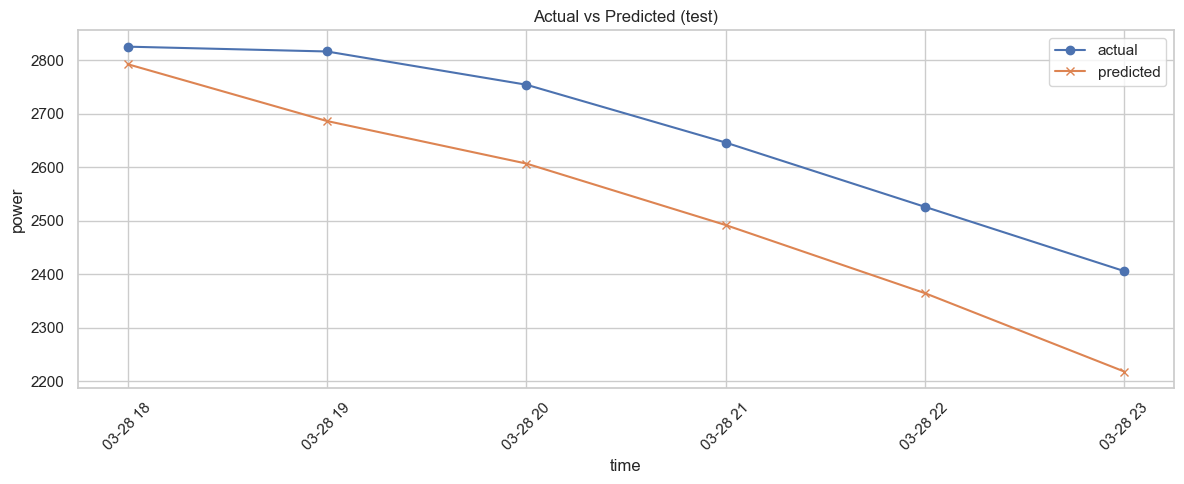

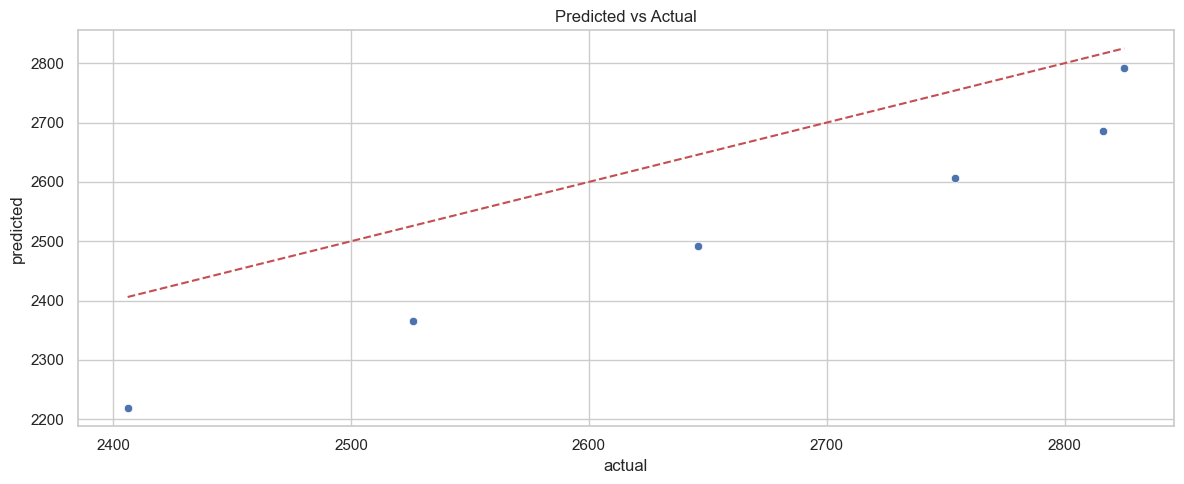

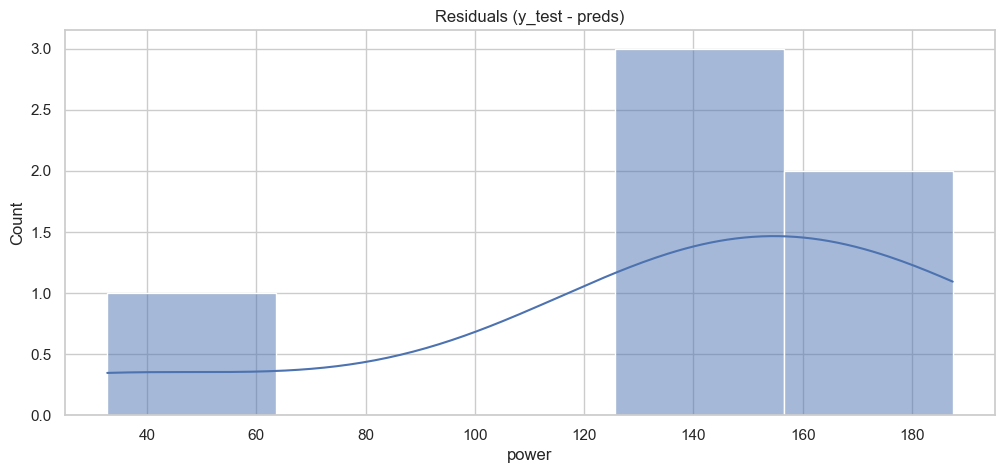

In [20]:
# 可視化: テスト期間の実測 vs 予測
if not globals().get('can_proceed', False):
    print('Skipping visualization: no model results available.')
else:
    test_idx = y_test.index
    plt.figure()
    plt.plot(test_idx, y_test, label='actual', marker='o')
    plt.plot(test_idx, preds, label='predicted', marker='x')
    plt.legend()
    plt.title('Actual vs Predicted (test)')
    plt.xlabel('time')
    plt.ylabel('power')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    # 散布図: 予測 vs 実測
    plt.figure()
    sns.scatterplot(x=y_test, y=preds)
    plt.xlabel('actual')
    plt.ylabel('predicted')
    plt.title('Predicted vs Actual')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.tight_layout()
    plt.show()
    # 残差ヒストグラム
    resid = y_test - preds
    plt.figure()
    sns.histplot(resid, kde=True)
    plt.title('Residuals (y_test - preds)')
    plt.show()

## 次のステップ
- 特徴量拡張: ラグ、移動平均、曜日/祝日フラグを追加
- モデル比較: ランダムフォレスト、XGBoost、ARIMA などを試す
- クロスバリデーション: 時系列クロスバリデーションで評価の安定化